# Task 4 — V1 High-Resolution Image EDA

**Status:** focused data audit. This notebook checks the optional V1 image variant.
It does not choose a model, metric, image transform, or query/gallery protocol.

**Owner:** Task 4 team


## 1. Audit question

What does V1 add beyond the supplied 60×80 teacher images?

This notebook checks provenance, missing/corrupt files, image geometry, storage cost,
and same-ID visual agreement. Label EDA is not repeated because V1 has no labels of
its own.


## 2. Safe data boundary

- V1 is an ID-keyed high-resolution variant of teacher train + test, never a new split.
- It inherits `partition`, `cv_fold`, and family groups from `data/processed/splits.csv`.
- Holdout, quarantine, and official test labels stay unread.
- All geometry and paired pixel summaries below use development rows only.
- Structural file counts may cover all roles because they contain no target values.


### 2.1 Focused V1 image-variant EDA

This audit answers one narrow question: what does V1 add beyond the teacher images?
It checks all V1 files structurally, then uses **development rows only** for image
distributions and paired pixel analysis. It does not create a split, fit statistics,
or read protected labels.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageOps


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/fashion").is_dir():
            return candidate
    raise RuntimeError("Could not locate the project root")


ROOT = find_project_root(Path.cwd())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from fashion.config import (  # noqa: E402
    PREDICTION_MANIFEST_CSV,
    SPLITS_CSV,
    TEACHER_TRAIN_CSV,
    TEST_CSV,
)
from fashion.data.dataset import load_splits  # noqa: E402
from fashion.data.hashing import write_deterministic_csv  # noqa: E402
from fashion.retrieval.external import (  # noqa: E402
    build_external_variant_index,
    compare_variant_pairs,
    ensure_external_image_audit,
    reconcile_external_ids,
    select_development_pairs,
)

V1_DIR = ROOT / "data/raw/external/fashion_product_images_v1"
V1_CSV = V1_DIR / "images.csv"
V1_IMAGE_DIR = V1_DIR / "images"
PROCESSED_DIR = ROOT / "data/processed/task4"
EVIDENCE_DIR = ROOT / "results/evidence/task4"
FIGURE_DIR = ROOT / "results/figures/task4"
for directory in (PROCESSED_DIR, EVIDENCE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

assert V1_CSV.is_file() and V1_IMAGE_DIR.is_dir()
print(f"Project root: {ROOT}")
print(f"V1 catalogue: {V1_CSV.relative_to(ROOT)}")
print("Safety rule: V1 inherits the existing split by ID; no new split is created.")

Project root: /localhome/local-lintran/MLA2
V1 catalogue: data/raw/external/fashion_product_images_v1/images.csv
Safety rule: V1 inherits the existing split by ID; no new split is created.


**Finding.** V1 is kept outside shared preparation. This notebook can audit it, but
all later training and evaluation rows must still come from the one saved split.

In [2]:
reconciliation, missing_external = reconcile_external_ids(
    V1_CSV,
    V1_IMAGE_DIR,
    TEACHER_TRAIN_CSV,
    TEST_CSV,
    root=ROOT,
)
assert reconciliation["catalogue_csv_matches_expected"]
assert reconciliation["catalogue_equals_teacher_union"]
assert reconciliation["catalogue_ids_outside_teacher"] == []
assert reconciliation["teacher_ids_missing_from_catalogue"] == []

reconciliation_rows = pd.DataFrame(
    [
        ("V1 catalogue IDs", reconciliation["catalogue_unique_ids"]),
        ("V1 JPEG files", reconciliation["valid_jpg_files"]),
        ("teacher train IDs", reconciliation["teacher_train_ids"]),
        ("teacher test IDs", reconciliation["teacher_test_ids"]),
        ("V1 ∩ teacher train", reconciliation["catalogue_train_overlap"]),
        ("V1 ∩ teacher test", reconciliation["catalogue_test_overlap"]),
        ("listed but missing images", len(reconciliation["catalogue_ids_without_image"])),
        ("files outside catalogue", len(reconciliation["image_ids_outside_catalogue"])),
    ],
    columns=["measure", "count"],
)
write_deterministic_csv(
    reconciliation_rows,
    EVIDENCE_DIR / "external_reconciliation.csv",
    index=False,
)
write_deterministic_csv(
    missing_external,
    EVIDENCE_DIR / "external_missing_images.csv",
    index=False,
)
(EVIDENCE_DIR / "external_provenance.json").write_text(
    json.dumps(reconciliation, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
display(reconciliation_rows)
display(missing_external)

,measure,count
0,V1 catalogue IDs,44446
1,V1 JPEG files,44441
2,teacher train IDs,38617
3,teacher test IDs,5829
4,V1 ∩ teacher train,38617
5,V1 ∩ teacher test,5829
6,listed but missing images,5
7,files outside catalogue,0


,id,teacher_role,issue
0,12347,train,catalogue_id_without_image
1,39401,train,catalogue_id_without_image
2,39403,train,catalogue_id_without_image
3,39410,train,catalogue_id_without_image
4,39425,train,catalogue_id_without_image


**Finding.** The 44,446 V1 catalogue IDs exactly equal 38,617 teacher-train
plus 5,829 teacher-test IDs. V1 is therefore the same catalogue at higher
resolution, not independent data. Its 44,441 files omit the same five unusable
teacher-train IDs: 12347, 39401, 39403, 39410, and 39425.

In [3]:
external_audit, audit_cache_used = ensure_external_image_audit(
    V1_IMAGE_DIR,
    PROCESSED_DIR / "external_image_audit.csv.gz",
    PROCESSED_DIR / "external_audit_cache.json",
    root=ROOT,
)
assert len(external_audit) == reconciliation["valid_jpg_files"]
assert external_audit["decode_ok"].all()

splits = load_splits(SPLITS_CSV)
variant_index = build_external_variant_index(splits, external_audit)
assert len(variant_index) == len(splits)
assert set(variant_index["partition"]) == {"development", "holdout", "quarantine"}
assert not {"articleType", "season", "gender", "usage"} & set(variant_index.columns)
write_deterministic_csv(
    variant_index,
    PROCESSED_DIR / "external_variant_index.csv.gz",
    index=False,
)

coverage = (
    variant_index.groupby("partition", observed=True)
    .size()
    .rename("v1_images")
    .reset_index()
    .sort_values("partition")
)
write_deterministic_csv(coverage, EVIDENCE_DIR / "external_split_coverage.csv", index=False)
reconciliation.update(
    {
        "decoded_files": int(external_audit["decode_ok"].sum()),
        "corrupt_files": int((~external_audit["decode_ok"]).sum()),
        "total_image_bytes": int(external_audit["file_size_bytes"].sum()),
        "decode_audit_cache_used": bool(audit_cache_used),
        "canonical_split_rows_with_v1": len(variant_index),
    }
)
(EVIDENCE_DIR / "external_provenance.json").write_text(
    json.dumps(reconciliation, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
print(f"Decode audit cache used: {audit_cache_used}")
display(coverage)

Decode audit cache used: True


,partition,v1_images
0,development,32773
1,holdout,5778
2,quarantine,61


**Finding.** Every one of the 44,441 V1 files decodes successfully. All 38,612
rows in the canonical teacher split have a matching V1 file. The join carries only
structural fields, so protected labels never enter this analysis.

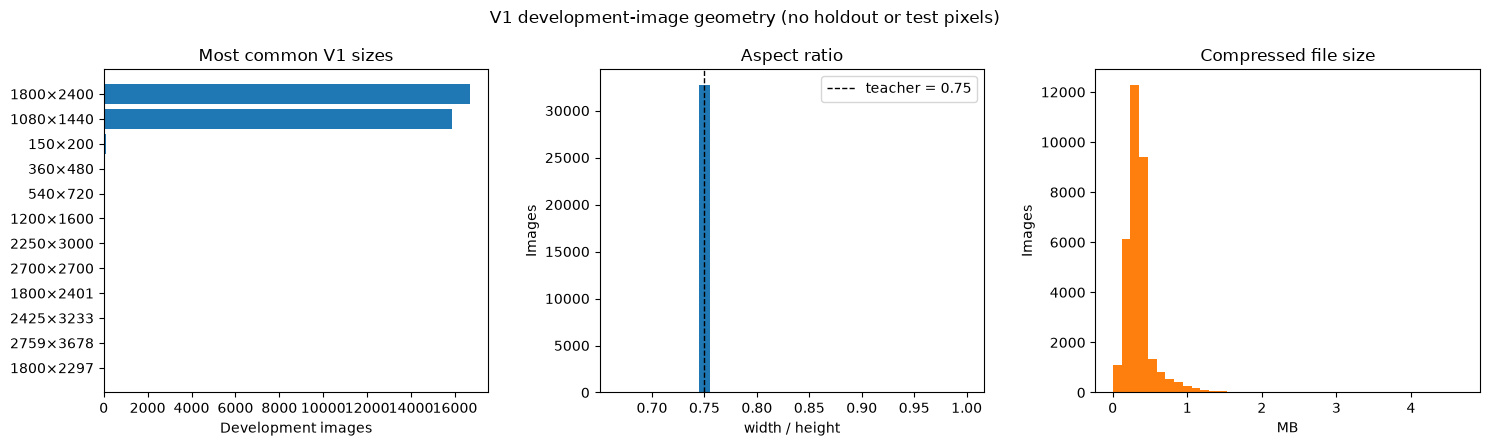

,external_width,external_height,external_mode,external_format,count,percentage
14,1800,2400,RGB,JPEG,16684,50.907759
7,1080,1440,RGB,JPEG,15870,48.424008
0,150,200,RGB,JPEG,109,0.332591
1,360,480,RGB,JPEG,51,0.155616
4,540,720,RGB,JPEG,20,0.061026
9,1200,1600,RGB,JPEG,5,0.015256
16,2250,3000,RGB,JPEG,4,0.012205
25,2700,2700,RGB,JPEG,3,0.009154
15,1800,2401,RGB,JPEG,2,0.006103
27,2759,3678,RGB,JPEG,2,0.006103


In [4]:
development_v1 = variant_index[variant_index["partition"].eq("development")].copy()
assert len(development_v1) == 32773

geometry_summary = (
    development_v1.groupby(
        ["external_width", "external_height", "external_mode", "external_format"],
        observed=True,
        dropna=False,
    )
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)
geometry_summary["percentage"] = 100 * geometry_summary["count"] / len(development_v1)
write_deterministic_csv(
    geometry_summary,
    EVIDENCE_DIR / "external_geometry_summary.csv",
    index=False,
    float_format="%.4f",
)

resolution_counts = (
    development_v1.assign(
        resolution=lambda frame: (
            frame["external_width"].astype(int).astype(str)
            + "×"
            + frame["external_height"].astype(int).astype(str)
        )
    )["resolution"]
    .value_counts()
    .head(12)
    .sort_values()
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].barh(resolution_counts.index, resolution_counts.values)
axes[0].set(title="Most common V1 sizes", xlabel="Development images")
axes[1].hist(development_v1["external_aspect_ratio"], bins=30, color="tab:blue")
axes[1].axvline(0.75, color="black", linestyle="--", linewidth=1, label="teacher = 0.75")
axes[1].set(title="Aspect ratio", xlabel="width / height", ylabel="Images")
axes[1].legend()
axes[2].hist(development_v1["external_file_size_bytes"] / 1_000_000, bins=40, color="tab:orange")
axes[2].set(title="Compressed file size", xlabel="MB", ylabel="Images")
fig.suptitle("V1 development-image geometry (no holdout or test pixels)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "external_geometry.png", dpi=180, bbox_inches="tight")
plt.show()
display(geometry_summary.head(12))

**Finding.** V1 is not uniformly “4K.” Most development images are 1080×1440
or 1800×2400, but there is a smaller low-resolution tail. The mixed sizes make an
explicit aspect-preserving resize rule necessary later; this EDA does not choose it.

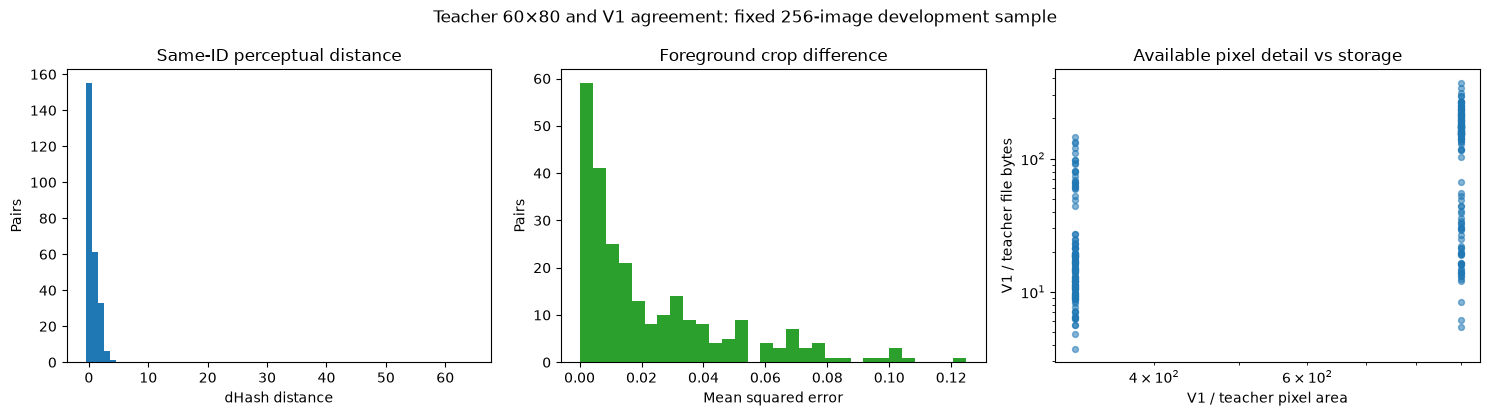

,pixel_area_ratio,file_size_ratio,dhash_distance,ahash_distance,crop_mse
count,256.000000,256.000000,256.000000,256.000000,256.000000
mean,632.250000,87.999262,0.582031,0.097656,0.023386
std,287.849961,88.097417,0.831435,0.297431,0.024909
min,324.000000,3.724565,0.000000,0.000000,0.000216
50%,900.000000,34.956835,0.000000,0.000000,0.013261
90%,900.000000,214.722904,2.000000,0.000000,0.062386
95%,900.000000,247.172728,2.000000,1.000000,0.074959
99%,900.000000,301.103068,3.000000,1.000000,0.103739
max,900.000000,371.632287,4.000000,1.000000,0.124880


In [5]:
pair_sample = select_development_pairs(variant_index, sample_size=256)
pair_agreement = compare_variant_pairs(pair_sample, root=ROOT)
write_deterministic_csv(
    pair_agreement,
    EVIDENCE_DIR / "same_id_agreement.csv",
    index=False,
    float_format="%.8f",
)

agreement_summary = pair_agreement[
    ["pixel_area_ratio", "file_size_ratio", "dhash_distance", "ahash_distance", "crop_mse"]
].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
write_deterministic_csv(
    agreement_summary.reset_index(names="statistic"),
    EVIDENCE_DIR / "same_id_agreement_summary.csv",
    index=False,
    float_format="%.8f",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(pair_agreement["dhash_distance"], bins=np.arange(-0.5, 65.5, 1))
axes[0].set(title="Same-ID perceptual distance", xlabel="dHash distance", ylabel="Pairs")
axes[1].hist(pair_agreement["crop_mse"], bins=30, color="tab:green")
axes[1].set(title="Foreground crop difference", xlabel="Mean squared error", ylabel="Pairs")
axes[2].scatter(
    pair_agreement["pixel_area_ratio"],
    pair_agreement["file_size_ratio"],
    alpha=0.55,
    s=18,
)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set(
    title="Available pixel detail vs storage",
    xlabel="V1 / teacher pixel area",
    ylabel="V1 / teacher file bytes",
)
fig.suptitle("Teacher 60×80 and V1 agreement: fixed 256-image development sample")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "same_id_agreement.png", dpi=180, bbox_inches="tight")
plt.show()
display(agreement_summary)

**Finding.** The fixed development sample measures two different facts. Hash and
crop differences check whether paired files still show the same product. Pixel-area
and file-size ratios show how much more image information and storage V1 makes
available. These are audit results, not proof that search accuracy will improve.


### 3.4 Paired examples

These four pairs are fixed quantiles of dHash agreement, not hand-picked successes.


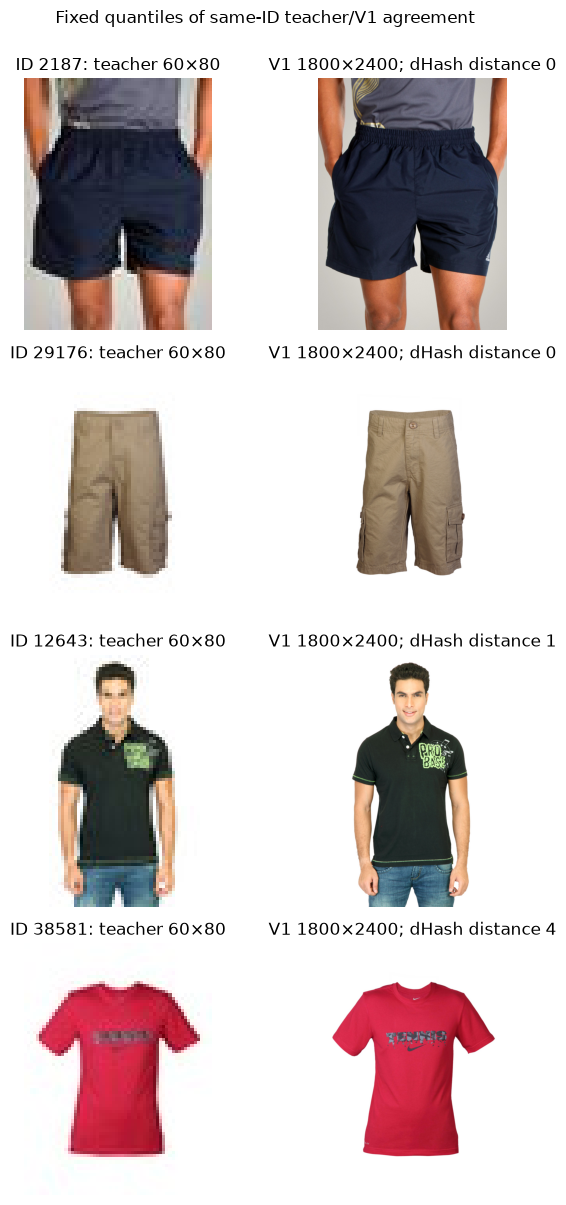

In [6]:
ordered_pairs = pair_agreement.sort_values(["dhash_distance", "id"]).reset_index(drop=True)
example_positions = np.linspace(0, len(ordered_pairs) - 1, 4, dtype=int)
examples = ordered_pairs.iloc[example_positions]

fig, axes = plt.subplots(len(examples), 2, figsize=(7, 12))
for row_index, row in enumerate(examples.itertuples(index=False)):
    teacher_path = ROOT / row.teacher_path
    external_path = ROOT / row.external_path
    with Image.open(teacher_path) as image:
        teacher = ImageOps.exif_transpose(image).convert("RGB").copy()
    with Image.open(external_path) as image:
        external = ImageOps.exif_transpose(image).convert("RGB").copy()
    axes[row_index, 0].imshow(teacher)
    axes[row_index, 0].set_title(f"ID {row.id}: teacher {teacher.width}×{teacher.height}")
    axes[row_index, 1].imshow(external)
    axes[row_index, 1].set_title(
        f"V1 {external.width}×{external.height}; dHash distance {row.dhash_distance}"
    )
    for axis in axes[row_index]:
        axis.axis("off")
fig.suptitle("Fixed quantiles of same-ID teacher/V1 agreement", y=1.0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "teacher_v1_pair_examples.png", dpi=180, bbox_inches="tight")
plt.show()

**Finding.** The paired examples support the ID match while showing the extra
visible detail V1 can provide. They also show why “higher resolution” is only a
candidate input choice: the main notebook must still compare retrieval quality and
cost before choosing V1.


## 4. EDA conclusion and handoff

- V1 is the same 44,446-ID catalogue as teacher train + test.
- V1 adds image resolution, not new products or labels.
- Five listed files are missing in both sources; all 44,441 present V1 files decode.
- Every canonical split row has a V1 image and keeps its existing partition/fold.
- V1 is mixed-resolution, so it must not be described as uniformly 4K.
- The main visual-search notebook must compare teacher and V1 retrieval quality and cost.

Evidence is saved under `results/evidence/task4/` and `results/figures/task4/`.
